In [1]:
import os
import pathlib
import pickle
import random
import re
import string
import urllib.request
import zipfile
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

import matplotlib.pyplot as plt

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"GPU доступен: {torch.cuda.is_available()}")

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Нет"

print(f"Имя GPU: {gpu_name}")
print(f"Используемое устройство: {device}")
print(f"Random seed: {SEED}")


GPU доступен: True
Имя GPU: NVIDIA GeForce RTX 3080
Используемое устройство: cuda
Random seed: 42


In [2]:
zip_path = pathlib.Path("rus-eng.zip")
extract_dir = pathlib.Path("rus-eng-data")
text_path = extract_dir / "rus.txt"

if not text_path.exists():
    if not zip_path.exists():
        print("Скачивание архива")
        url = "https://www.manythings.org/anki/rus-eng.zip"
        req = urllib.request.Request(
            url,
            headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"},
        )

        with urllib.request.urlopen(req, timeout=15) as response, open(zip_path, "wb") as out_file:
            chunk_size = 1024 * 1024
            downloaded = 0

            while True:
                chunk = response.read(chunk_size)
                if not chunk:
                    break

                out_file.write(chunk)
                downloaded += len(chunk)
                print(f"Загружено: {downloaded / (1024 * 1024):.1f} MB", end="\r")

        print("\nСкачивание завершено")

    print("Распаковка архива")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Распаковка завершена")
else:
    print("Файл rus.txt уже существует")


Файл rus.txt уже существует


In [3]:
with open(text_path, encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]

text_pairs = []

for line in lines:
    parts = line.split("\t")

    if len(parts) >= 2:
        english, russian = parts[0], parts[1]
        russian = f"[start] {russian} [end]"
        text_pairs.append((english, russian))


In [4]:
random.shuffle(text_pairs)

train_len = int(0.85 * len(text_pairs))
val_len = int(0.075 * len(text_pairs))

train_pairs = text_pairs[:train_len]
val_pairs = text_pairs[train_len:train_len + val_len]
test_pairs = text_pairs[train_len + val_len:]

print(f"Общее количество предложений: {len(text_pairs)}")
print(f"Размер обучающей выборки: {len(train_pairs)}")
print(f"Размер валидационной выборки: {len(val_pairs)}")
print(f"Размер тестовой выборки: {len(test_pairs)}")


Общее количество предложений: 536124
Размер обучающей выборки: 455705
Размер валидационной выборки: 40209
Размер тестовой выборки: 40210


In [5]:
PAD_IDX = 0
UNK_IDX = 1

strip_chars = string.punctuation.replace("[", "").replace("]", "")


def custom_standardization(input_string):
    lowercase = input_string.lower()
    return re.sub(f"[{re.escape(strip_chars)}]", "", lowercase)


def english_standardization(input_string):
    lowercase = input_string.lower()
    return re.sub(f"[{re.escape(string.punctuation)}]", "", lowercase)


class TextVectorization:
    def __init__(
        self,
        max_tokens,
        output_sequence_length,
        standardize=None,
        special_tokens=None,
    ):
        self.max_tokens = max_tokens
        self.output_sequence_length = output_sequence_length
        self.standardize = standardize
        self.special_tokens = special_tokens or []

        self.vocab = ["", "[UNK]"] + self.special_tokens

        self.word_to_index = {
            word: idx
            for idx, word in enumerate(self.vocab)
        }

    def adapt(self, texts):
        counts = Counter()

        for text in texts:
            clean_text = (
                self.standardize(text) if self.standardize else english_standardization(text)
            )

            tokens = clean_text.split()
            counts.update(tokens)

        max_words = self.max_tokens - len(self.vocab)

        for word, _ in counts.most_common(max_words):
            if word not in self.word_to_index:
                self.word_to_index[word] = len(self.vocab)
                self.vocab.append(word)

    def get_vocabulary(self):
        return self.vocab

    def encode(self, text):
        clean_text = (
            self.standardize(text) if self.standardize else english_standardization(text)
        )

        tokens = clean_text.split()
        ids = [
            self.word_to_index.get(token, UNK_IDX)
            for token in tokens[:self.output_sequence_length]
        ]

        ids += [PAD_IDX] * (self.output_sequence_length - len(ids))

        return ids

    def __call__(self, texts):
        if isinstance(texts, str):
            texts = [texts]

        encoded_list = [self.encode(text) for text in texts]

        return torch.tensor(encoded_list, dtype=torch.long)


vocab_size = 25000
sequence_length = 20

english_tokenizer = TextVectorization(
    max_tokens=vocab_size,
    output_sequence_length=sequence_length,
)

russian_tokenizer = TextVectorization(
    max_tokens=vocab_size,
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
    special_tokens=["[start]", "[end]"],
)

train_english_texts = [pair[0] for pair in train_pairs]
train_russian_texts = [pair[1] for pair in train_pairs]

english_tokenizer.adapt(train_english_texts)
russian_tokenizer.adapt(train_russian_texts)

print("Токенизаторы успешно адаптированы")
print(f"Размер английского словаря: {len(english_tokenizer.get_vocabulary())}")
print(f"Размер русского словаря: {len(russian_tokenizer.get_vocabulary())}")

Токенизаторы успешно адаптированы
Размер английского словаря: 17991
Размер русского словаря: 24998


In [6]:
batch_size = 64


class TranslationDataset(Dataset):
    def __init__(self, pairs, eng_tokenizer, rus_tokenizer):
        eng_texts = [pair[0] for pair in pairs]
        rus_texts = [pair[1] for pair in pairs]

        self.eng_tensors = eng_tokenizer(eng_texts)
        self.rus_tensors = rus_tokenizer(rus_texts)

    def __len__(self):
        return len(self.eng_tensors)

    def __getitem__(self, idx):
        eng_tensor = self.eng_tensors[idx]
        rus_tensor = self.rus_tensors[idx]

        features = {
            "english": eng_tensor,
            "russian": rus_tensor[:-1],
        }

        labels = rus_tensor[1:]

        return features, labels


def make_dataset(pairs, shuffle=True):
    dataset = TranslationDataset(
        pairs,
        eng_tokenizer=english_tokenizer,
        rus_tokenizer=russian_tokenizer,
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


train_ds = make_dataset(train_pairs, shuffle=True)
val_ds = make_dataset(val_pairs, shuffle=False)
test_ds = make_dataset(test_pairs, shuffle=False)

print(f"Количество train batch: {len(train_ds)}")
print(f"Количество val batch: {len(val_ds)}")
print(f"Количество test batch: {len(test_ds)}")


Количество train batch: 7121
Количество val batch: 629
Количество test batch: 629


In [7]:
class Seq2SeqWithAttention(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        embed_dim=256,
        hidden_dim=512,
        dropout=0.3,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.encoder_embedding = nn.Embedding(
            src_vocab_size, embed_dim, padding_idx=PAD_IDX
        )
        self.encoder_gru = nn.GRU(
            embed_dim, hidden_dim, batch_first=True, bidirectional=True
        )
        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)

        self.attn_W = nn.Linear(hidden_dim * 2, hidden_dim, bias=False)

        self.decoder_embedding = nn.Embedding(
            tgt_vocab_size, embed_dim, padding_idx=PAD_IDX
        )
        self.decoder_gru = nn.GRU(
            embed_dim + hidden_dim * 2, hidden_dim, batch_first=True
        )
        self.fc_concat = nn.Linear(hidden_dim + hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, tgt_vocab_size)

    def _combine_encoder_hidden(self, h_n):

        forward = h_n[-2, :, :]
        backward = h_n[-1, :, :]
        hidden_cat = torch.cat((forward, backward), dim=-1)
        hidden = torch.tanh(self.fc_hidden(hidden_cat))
        return hidden.unsqueeze(0)

    def _attention(self, hidden, encoder_outputs, source_mask):

        query = hidden.squeeze(0).unsqueeze(1)

        source_mask = source_mask[:, :encoder_outputs.size(1)]
        
        attn_energy = torch.bmm(
            query,
            self.attn_W(encoder_outputs).transpose(1, 2),
        )

        attn_energy = attn_energy.masked_fill(
            ~source_mask.unsqueeze(1),
            float("-inf"),
        )

        attn_weights = torch.softmax(attn_energy, dim=-1)

        context = torch.bmm(attn_weights, encoder_outputs)

        return context

    def encode(self, source):
        lengths = (source != PAD_IDX).sum(dim=1).cpu()
        x_enc = self.dropout(self.encoder_embedding(source))
        packed_x = nn.utils.rnn.pack_padded_sequence(
            x_enc, lengths, batch_first=True, enforce_sorted=False
        )
        packed_outputs, h_n = self.encoder_gru(packed_x)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(
            packed_outputs, batch_first=True
        )
        hidden = self._combine_encoder_hidden(h_n)
        return outputs, hidden

    def forward(self, source, target, teacher_forcing_ratio=1.0):
        batch_size = source.size(0)
        target_len = target.size(1)
        tgt_vocab_size = self.fc.out_features

        source_mask = source != PAD_IDX

        encoder_outputs, hidden = self.encode(source)

        outputs = torch.zeros(batch_size, target_len, tgt_vocab_size, device=source.device)

        input_token = target[:, 0].unsqueeze(1)

        for t in range(target_len):
            x_dec = self.decoder_embedding(input_token)
            context = self._attention(
                hidden,
                encoder_outputs,
                source_mask,
            )

            dec_input = torch.cat((x_dec, context), dim=-1)
            dec_output, hidden = self.decoder_gru(dec_input, hidden)

            combined = torch.cat((dec_output, context), dim=-1)
            combined = torch.tanh(self.fc_concat(combined))
            logits = self.fc(combined)

            outputs[:, t:t+1, :] = logits

            predicted_token = logits.argmax(dim=-1)
            if t < target_len - 1:
                use_teacher = random.random() < teacher_forcing_ratio
                if use_teacher:
                    input_token = target[:, t+1].unsqueeze(1)
                else:
                    input_token = predicted_token

        return outputs

    @torch.no_grad()
    def translate(self, source_tensor, start_token_idx, end_token_idx, max_len=20):
        self.eval()
        device = next(self.parameters()).device
        source_tensor = source_tensor.to(device)
        if source_tensor.dim() == 1:
            source_tensor = source_tensor.unsqueeze(0)

        source_mask = source_tensor != PAD_IDX

        encoder_outputs, hidden = self.encode(source_tensor)

        curr_token = torch.tensor([[start_token_idx]], device=device, dtype=torch.long)
        decoded_tokens = []

        for _ in range(max_len):
            x_dec = self.decoder_embedding(curr_token)

            context = self._attention(
                hidden,
                encoder_outputs,
                source_mask,
            )

            dec_input = torch.cat((x_dec, context), dim=-1)
            dec_output, hidden = self.decoder_gru(dec_input, hidden)

            combined = torch.cat((dec_output, context), dim=-1)
            combined = torch.tanh(self.fc_concat(combined))
            logits = self.fc(combined)

            next_token = torch.argmax(logits, dim=-1)
            token_id = next_token.item()
            if token_id == end_token_idx:
                break
            decoded_tokens.append(token_id)
            curr_token = next_token

        return decoded_tokens

In [8]:
embed_dim = 256
hidden_dim = 512

src_vocab_size = len(english_tokenizer.get_vocabulary())
tgt_vocab_size = len(russian_tokenizer.get_vocabulary())

seq2seq_rnn = Seq2SeqWithAttention(
    src_vocab_size=src_vocab_size,
    tgt_vocab_size=tgt_vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    dropout=0.3,
).to(device)

print(seq2seq_rnn)
total_params = sum(p.numel() for p in seq2seq_rnn.parameters())
print(f"Всего параметров: {total_params:,}")

Seq2SeqWithAttention(
  (encoder_embedding): Embedding(17991, 256, padding_idx=0)
  (encoder_gru): GRU(256, 512, batch_first=True, bidirectional=True)
  (fc_hidden): Linear(in_features=1024, out_features=512, bias=True)
  (attn_W): Linear(in_features=1024, out_features=512, bias=False)
  (decoder_embedding): Embedding(24998, 256, padding_idx=0)
  (decoder_gru): GRU(1280, 512, batch_first=True)
  (fc_concat): Linear(in_features=1536, out_features=512, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=24998, bias=True)
)
Всего параметров: 30,786,214


In [9]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [10]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

optimizer = optim.AdamW(
    seq2seq_rnn.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=True
)

early_stopping = EarlyStopping(patience=3, min_delta=1e-4)

epochs = 20
clip_val = 1.0

best_val_loss = float("inf")
teacher_forcing_start = 1.0
teacher_forcing_end = 0.5

history_train_loss = []
history_val_loss = []

for epoch in range(1, epochs + 1):
    progress = (epoch - 1) / max(epochs - 1, 1)
    teacher_forcing_ratio = teacher_forcing_start - progress * (teacher_forcing_start - teacher_forcing_end)

    seq2seq_rnn.train()
    train_loss = 0.0
    train_pbar = tqdm(train_ds, desc=f"Эпоха {epoch:02d}/{epochs:02d} [Train]")
    for batch_features, batch_labels in train_pbar:
        source = batch_features["english"].to(device)
        target = batch_features["russian"].to(device)
        labels = batch_labels.to(device)

        optimizer.zero_grad()
        outputs = seq2seq_rnn(source, target, teacher_forcing_ratio=teacher_forcing_ratio)
        loss = criterion(outputs.reshape(-1, tgt_vocab_size), labels.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(seq2seq_rnn.parameters(), max_norm=clip_val)
        optimizer.step()

        train_loss += loss.item()
        train_pbar.set_postfix(loss=f"{loss.item():.4f}", tf=f"{teacher_forcing_ratio:.2f}")

    avg_train_loss = train_loss / len(train_ds)

    seq2seq_rnn.eval()
    val_loss = 0.0
    val_pbar = tqdm(val_ds, desc=f"Эпоха {epoch:02d}/{epochs:02d} [Val]")
    with torch.no_grad():
        for batch_features, batch_labels in val_pbar:
            source = batch_features["english"].to(device)
            target = batch_features["russian"].to(device)
            labels = batch_labels.to(device)

            outputs = seq2seq_rnn(source, target, teacher_forcing_ratio=1.0)
            loss = criterion(outputs.reshape(-1, tgt_vocab_size), labels.reshape(-1))
            val_loss += loss.item()
            val_pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_val_loss = val_loss / len(val_ds)

    history_train_loss.append(avg_train_loss)
    history_val_loss.append(avg_val_loss)

    print(
        f"Итог эпохи {epoch:02d}/{epochs:02d} | "
        f"Train Loss: {avg_train_loss:.4f}\n"
        f"Val Loss:   {avg_val_loss:.4f}\n"
        f"Teacher Forcing: {teacher_forcing_ratio:.2f}"
    )

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            "epoch": epoch,
            "model_state": seq2seq_rnn.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss": avg_val_loss,
            "teacher_forcing_ratio": teacher_forcing_ratio,
            "history_train_loss": history_train_loss,
            "history_val_loss": history_val_loss,
        }, "best_seq2seq_model.pt")
        print("Сохранена новая лучшая модель")

    early_stopping(avg_val_loss)
    if early_stopping.early_stop:
        print("Завершаем обучение")
        break

C:\Users\kiru\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Эпоха 01/20 [Val]: 100%|████████████████████████████████████████████████| 629/629 [00:12<00:00, 49.65it/s, loss=2.3669]


Итог эпохи 01/20 | Train Loss: 2.7208
Val Loss:   1.8619
Teacher Forcing: 1.00
Сохранена новая лучшая модель


Эпоха 02/20 [Val]: 100%|████████████████████████████████████████████████| 629/629 [00:12<00:00, 51.60it/s, loss=2.2748]


Итог эпохи 02/20 | Train Loss: 1.8213
Val Loss:   1.6899
Teacher Forcing: 0.97
Сохранена новая лучшая модель


Эпоха 03/20 [Val]: 100%|████████████████████████████████████████████████| 629/629 [00:11<00:00, 53.62it/s, loss=1.9842]


...

Итог эпохи 04/20 | Train Loss: 1.6676
Val Loss:   1.6637
Teacher Forcing: 0.92


Эпоха 05/20 [Val]: 100%|████████████████████████████████████████████████| 629/629 [00:11<00:00, 53.22it/s, loss=2.1625]


Итог эпохи 05/20 | Train Loss: 1.6802
Val Loss:   1.6799
Teacher Forcing: 0.89


Эпоха 06/20 [Val]: 100%|████████████████████████████████████████████████| 629/629 [00:11<00:00, 53.26it/s, loss=2.2250]

Итог эпохи 06/20 | Train Loss: 1.7012
Val Loss:   1.6924
Teacher Forcing: 0.87
Завершаем обучение


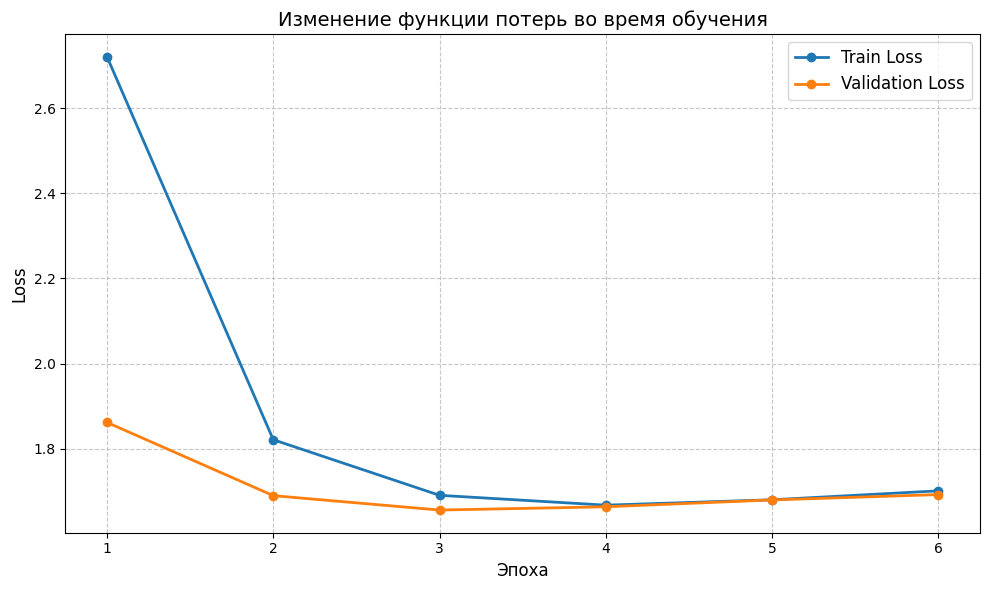

In [11]:
epochs_range = range(1, len(history_train_loss) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history_train_loss,
    marker="o",
    linewidth=2,
    label="Train Loss",
)

plt.plot(
    epochs_range,
    history_val_loss,
    marker="o",
    linewidth=2,
    label="Validation Loss",
)

plt.title(
    "Изменение функции потерь во время обучения",
    fontsize=14,
)

plt.xlabel("Эпоха", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.xticks(epochs_range)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [12]:
checkpoint = torch.load(
    "best_seq2seq_model.pt",
    map_location=device,
    weights_only=False,
)

seq2seq_rnn.load_state_dict(checkpoint["model_state"])
seq2seq_rnn.eval()

print("Лучшая модель успешно загружена")
print(f"Лучшая эпоха: {checkpoint['epoch']}")
print(f"Лучший Val Loss: {checkpoint['val_loss']:.4f}")
print(f"Teacher Forcing: {checkpoint['teacher_forcing_ratio']:.2f}")


Лучшая модель успешно загружена
Лучшая эпоха: 3
Лучший Val Loss: 1.6561
Teacher Forcing: 0.95


In [13]:
seq2seq_rnn.eval()

test_loss = 0.0
test_pbar = tqdm(test_ds, desc="Тестирование модели")

with torch.no_grad():
    for batch_features, batch_labels in test_pbar:
        source = batch_features["english"].to(device)
        target = batch_features["russian"].to(device)
        labels = batch_labels.to(device)

        outputs = seq2seq_rnn(
            source,
            target,
            teacher_forcing_ratio=0.0,
        )

        loss = criterion(
            outputs.reshape(-1, tgt_vocab_size),
            labels.reshape(-1),
        )

        test_loss += loss.item()
        test_pbar.set_postfix(loss=f"{loss.item():.4f}")

avg_test_loss = test_loss / len(test_ds)

print("\nРезультаты тестирования модели")
print(f"Test Loss: {avg_test_loss:.4f}")


Тестирование модели: 100%|██████████████████████████████████████████████| 629/629 [00:11<00:00, 54.69it/s, loss=2.6364]


Результаты тестирования модели
Test Loss: 3.3033


In [14]:
def tokens_to_words(token_ids, vocabulary, start_idx, end_idx):
    words = []

    for idx in token_ids:
        if idx == PAD_IDX:
            continue

        if idx == UNK_IDX:
            continue

        if idx == start_idx:
            continue

        if idx == end_idx:
            break

        if 0 <= idx < len(vocabulary):
            words.append(vocabulary[idx])

    return words


In [15]:
seq2seq_rnn.eval()

references = []
hypotheses = []

print(
    f"Расчёт BLEU на {len(test_pairs)} предложениях"
)

start_idx = russian_tokenizer.word_to_index["[start]"]
end_idx = russian_tokenizer.word_to_index["[end]"]
rus_vocab = russian_tokenizer.get_vocabulary()

for english_text, russian_text in tqdm(
    test_pairs,
    desc="BLEU evaluation",
):
    source_tensor = english_tokenizer([english_text]).to(device)

    pred_token_ids = seq2seq_rnn.translate(
        source_tensor=source_tensor,
        start_token_idx=start_idx,
        end_token_idx=end_idx,
        max_len=sequence_length,
    )

    predicted_words = tokens_to_words(
        pred_token_ids,
        rus_vocab,
        start_idx,
        end_idx,
    )

    reference_tensor = russian_tokenizer([russian_text])[0].cpu().tolist()

    reference_words = tokens_to_words(
        reference_tensor,
        rus_vocab,
        start_idx,
        end_idx,
    )

    if len(reference_words) == 0:
        continue

    hypotheses.append(predicted_words)
    references.append([reference_words])

smoothing = SmoothingFunction().method1

bleu_score = corpus_bleu(
    references,
    hypotheses,
    smoothing_function=smoothing,
)

print(f"\nCorpus BLEU Score: {bleu_score:.4f}")
print(f"Corpus BLEU Score: {bleu_score * 100:.2f}%")


Расчёт BLEU на 40210 предложениях


BLEU evaluation: 100%|██████████████████████████████████████████████████████████| 40210/40210 [04:02<00:00, 165.89it/s]



Corpus BLEU Score: 0.2843
Corpus BLEU Score: 28.43%


In [16]:
def generate_translation(input_sentence: str) -> str:
    seq2seq_rnn.eval()
    source_tensor = english_tokenizer([input_sentence]).to(device)

    start_idx = russian_tokenizer.word_to_index["[start]"]
    end_idx = russian_tokenizer.word_to_index["[end]"]

    pred_token_ids = seq2seq_rnn.translate(
        source_tensor=source_tensor,
        start_token_idx=start_idx,
        end_token_idx=end_idx,
        max_len=sequence_length,
    )

    rus_vocab = russian_tokenizer.get_vocabulary()

    translated_words = [
        rus_vocab[idx]
        for idx in pred_token_ids
        if (
            idx != PAD_IDX
            and idx != UNK_IDX
            and 0 <= idx < len(rus_vocab)
        )
    ]

    return " ".join(translated_words)


custom_sentences = [
    "Hello world!",
    "I love machine learning.",
    "Where is the nearest bank?",
    "She has a dog.",
    "How are you today?",
]

print("\nПримеры перевода:\n")

for sentence in custom_sentences:
    translation = generate_translation(sentence)

    print(f"Исходный текст: {sentence}")
    print(f"Перевод: {translation}")
    print("-")



Примеры перевода:

Исходный текст: Hello world!
Перевод: здравствуйте мир
-
Исходный текст: I love machine learning.
Перевод: я люблю изучать английский
-
Исходный текст: Where is the nearest bank?
Перевод: где ближайшая банк
-
Исходный текст: She has a dog.
Перевод: у неё собака
-
Исходный текст: How are you today?
Перевод: как вы сегодня
-


In [17]:
with open("english_tokenizer.pkl", "wb") as f:
    pickle.dump(english_tokenizer, f)

with open("russian_tokenizer.pkl", "wb") as f:
    pickle.dump(russian_tokenizer, f)

model_config = {
    "src_vocab_size": src_vocab_size,
    "tgt_vocab_size": tgt_vocab_size,
    "embed_dim": embed_dim,
    "hidden_dim": hidden_dim,
    "dropout": 0.3,
    "sequence_length": sequence_length,
}

with open("model_config.pkl", "wb") as f:
    pickle.dump(model_config, f)

print("Модель и связанные компоненты успешно сохранены")


Модель и связанные компоненты успешно сохранены
